In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

In [3]:
data=pd.read_csv('BodyWeight.csv')
data.head()

,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.82,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male


In [4]:
#now we will be exploring all the datasets
print("Shape of the dataset:",data.shape)
print()
print(data.info())
print()
print(data.describe())

Shape of the dataset: (10, 4)

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  10 non-null     int64  
 1   Height  10 non-null     float64
 2   Age     10 non-null     int64  
 3   Gender  10 non-null     str    
dtypes: float64(1), int64(2), str(1)
memory usage: 452.0 bytes
None

          Weight     Height        Age
count  10.000000  10.000000  10.000000
mean   72.600000   1.701000  40.300000
std    10.834103   0.118832  22.181323
min    55.000000   1.500000  16.000000
25%    69.000000   1.647500  25.500000
50%    70.000000   1.690000  37.000000
75%    77.500000   1.795000  49.500000
max    95.000000   1.870000  89.000000


In [5]:
#now we will check the missing values
data.isnull().sum()


Weight    0
Height    0
Age       0
Gender    0
dtype: int64

In [7]:
#now we will encounter the gender
encode=LabelEncoder()
data["Gender"]=encode.fit_transform(data["Gender"])
data.head()

,Weight,Height,Age,Gender
0,79,1.80,35,1
1,69,1.68,39,1
2,73,1.82,25,1
3,95,1.70,60,1
4,82,1.87,27,1


In [ ]:
#we are defining the features and targets here
X=data[["Height","Age","Gender"]]
y=data["Weight"]

In [10]:
#now we will be splitting the dataset for training and testing 
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
#Now we will be training the model using linear regeression 
model=LinearRegression()
model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[32.84, 0.32,14.62]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Height','Age','Gender']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.055
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [12]:
#now the model is trained and we will be predicting the values using the test data
y_pred=model.predict(X_test)
print(y_pred)

[56.85651025 79.10576115]


In [16]:
#now since the prediction is done we will be evaluating the model using metrics like mean squared error (mse)and r2 score to check the accuracy of the #model
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("r2 score :",r2_score(y_test,y_pred))

Mean Absolute Error: 8.624625451606978
Mean Squared Error: 76.57792714844265
r2 score : -11.252468343750825


In [17]:
#model equation
print("Intercept :", model.intercept_)
print("Coefficients :", model.coef_)

Intercept : -3.0552172392595196
Coefficients : [32.8353363   0.31729474 14.62311848]


In [18]:
#predicting a new person
new_person = [[1.75, 30, 1]]
prediction = model.predict(new_person)
print("Predicted Weight =", prediction[0], "kg")

Predicted Weight = 78.548582018849 kg


c:\Users\K Satya Sai Sailesh\MLlab\Machine-Learning-Lab\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


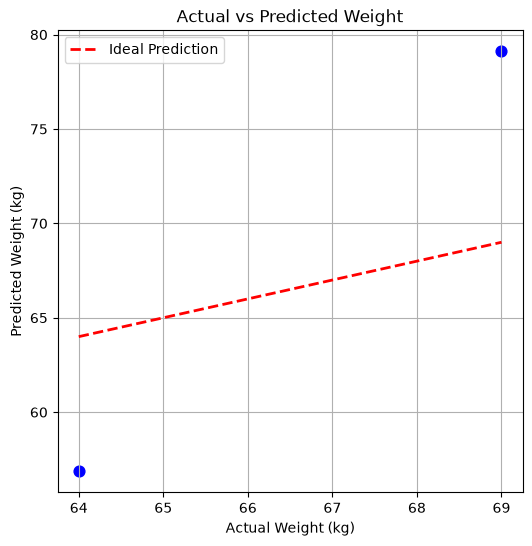

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color="blue", s=60)
# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red",
         linestyle="--",
         linewidth=2,
         label="Ideal Prediction")
plt.xlabel("Actual Weight (kg)")
plt.ylabel("Predicted Weight (kg)")
plt.title("Actual vs Predicted Weight")
plt.legend()
plt.grid(True)
plt.show()